In [1]:
#NO QUIERO RESOLVER UNA EDO
#Solo quiero encontrar una funcion f a partir de sus datos
#Si funciona, a ver si puedo implementarlo para encontrar la f de x'=f(x)
#Voy a aplicar Direct Sindy-KAN: las aristas de la red son directamente las funciones simbólicas del diccionario
#Los únicos parámetros que hay que aprender son los coeficientes de Xi y Lambda_shadow

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

#Genero un numero aleatorio a partir del 37
torch.manual_seed(37)

In [41]:
# GENERACIÓN DE DATOS
# Dominio x entre -2.5 y 2.5 (como en el 4.1 del paper SINDy-KANs)
x = torch.linspace(-2.5, 2.5, 1000).unsqueeze(1) #unsqueeze(1) hace que la fila de numeros sea un vector columna

# La fórmula que quiero descubrir: y = 2*sin(x) - 0.5*x^2
y_true = 2.0 * torch.sin(x) - 0.5 * (x ** 2)

print(f'Forma de x:', x.shape) #Vector de 1000 x 1
print(f'Forma de y_true:', y_true.shape) #Vector de 1000 x 1

Forma de x: torch.Size([1000, 1])
Forma de y_true: torch.Size([1000, 1])


In [42]:
# Construimos la matriz Theta univariada de la arista
def build_theta(x_data):
    return torch.cat([
        torch.ones_like(x_data), # 1
        x_data,                  # x
        x_data**2,               # x^2
        x_data**3,               # x^3
        torch.sin(x_data),       # sin(x)
        torch.cos(x_data)        # cos(x)
    ], dim=1)                    #dim=1 pega las funciones en columnas, con dim=0 seria en filas

Theta = build_theta(x)
print(f"Forma de Theta",Theta.shape)
num_features = Theta.shape[1] # 6 funciones candidatas

Forma de Theta torch.Size([1000, 6])


In [43]:
#PARÁMETROS DE LA DIRECT SINDy-KAN
# Xi = la matriz a la que hay que encontrar los coeficientes (sparse)
j=torch.randn(num_features, 1) * 0.1
Xi = torch.nn.Parameter(j) #son 6 parametros (que empiezan siendo aleatorios y pequeños) que PyTorch debe entrenar

# Lambda: La "matriz sombra" para forzar esparsidad con ADAM
Lambda_shadow = torch.nn.Parameter(torch.randn(num_features, 1) * 0.1)
#Como Lambda es un Parameter, el optimizador tmb se encargará de entrenarlo

#Xi y Lambda son matrices pero de 6x1 porque solo uso una capa (layer) en todo el ejercicio 

#¿CÓMO PUEDO IMPLEMENTAR MÁS CAPAS?

In [48]:
# ENTRENAMIENTO CON LA FUNCIÓN DE PÉRDIDA (Loss) SINDy-KAN
optimizer = optim.Adam([Xi, Lambda_shadow], lr=0.001) #SOLO entreno Xi y Lambda_shadow

#lr =learning rate es el salto que dan los parametros en cada iteracion
#lr lo cojo viendo la tabla 4 pero ns si debería de poder deducirlo 

# Hiperparámetros de pérdida (similares a la Tabla 4 del paper), indican la importancia que le damos a cada factor en el entrenamiento
lam_S = 1.0      # Peso del error de Xi
lam_L = 1.0      # Peso del error de Lambda
lam_1 = 0.05     # Regularización L1 para el sparse. En el articulo dicen que debe ser del mismo orden de magnitud que el error esperado del sistema
lam_2 = 0.5      # Parecido entre Xi y Lambda_shadow

iteraciones = 10000
loss_history = []

for k in range(iteraciones):
    optimizer.zero_grad() #pongo a 0 los gradientes de Xi y Lambda_shadow
    
    # Predicciones 
    y_pred_xi = Theta @ Xi
    y_pred_lam = Theta @ Lambda_shadow
    
    # Construcción de la Ecuación 39 (Apéndice A)
    L_S = torch.mean((y_true - y_pred_xi)**2)          #Error cuadratico medio usando Xi
    L_L = torch.mean((y_true - y_pred_lam)**2)         #Error cuadratico medio usando Lambda_shadow
    L_1 = torch.norm(Lambda_shadow, p=1)               # Norma L1 (Cuenta ceros)
    L_2 = torch.mean((Lambda_shadow - Xi)**2)          # Distancia euclídea al cuadrado
    
    # Pérdida Total
    loss = lam_S * L_S + lam_L * L_L + lam_1 * L_1 + lam_2 * L_2
    loss.backward() #backpropation: se calcula los gradientes de cada elemento de Xi y Lambda_shadow respecto a la Loss Fonction
                    #Tengo que leer luego para entender lo que hace internamente bien
    optimizer.step() #el optimizador de ADAM que configuré fuera del bucle actualiza los valores de Xi y Lambda_shadow
    
    if k % 1000 == 0:
        print(f"Iter {k} | Loss: {loss.item():.4f} | L1 Norm: {L_1.item():.4f}")



Iter 0 | Loss: 0.1238 | L1 Norm: 2.4218
Iter 1000 | Loss: 0.1229 | L1 Norm: 2.4141
Iter 2000 | Loss: 0.1229 | L1 Norm: 2.4150
Iter 3000 | Loss: 0.1229 | L1 Norm: 2.4137
Iter 4000 | Loss: 0.1229 | L1 Norm: 2.4132
Iter 5000 | Loss: 0.1229 | L1 Norm: 2.4132
Iter 6000 | Loss: 0.1228 | L1 Norm: 2.4136
Iter 7000 | Loss: 0.1229 | L1 Norm: 2.4141
Iter 8000 | Loss: 0.1228 | L1 Norm: 2.4139
Iter 9000 | Loss: 0.1228 | L1 Norm: 2.4134


In [49]:
#UMBRAL SECUENCIAL (Simulando STLSQ)
# Al terminar, cortamos los coeficientes pequeños que sobrevivieron como ruido
Xi_final = Xi.detach().clone()  #detach avisa de que ya no siguen entrenando los parametros
threshold = 0.1 #umbral
Xi_final[Xi_final.abs() < threshold] = 0.0

In [50]:
# RESULTADOS
print("--- ECUACIÓN DESCUBIERTA POR DIRECT SINDy-KAN ---")
features = ["1", "x", "x^2", "x^3", "sin(x)", "cos(x)"]
ecuacion = []
for i in range(num_features):
    coef = Xi_final[i].item()  #convierto el numero que habia en el tensor Xi_final en un numero normal
    if coef != 0:
        ecuacion.append(f"{coef:.4f}*{features[i]}")

print("y = " + " + ".join(ecuacion))
print("Ecuación Real: y = -0.5*x^2 + 2.0*sin(x)")

--- ECUACIÓN DESCUBIERTA POR DIRECT SINDy-KAN ---
y = -0.4998*x^2 + 1.8874*sin(x)
Ecuación Real: y = -0.5*x^2 + 2.0*sin(x)


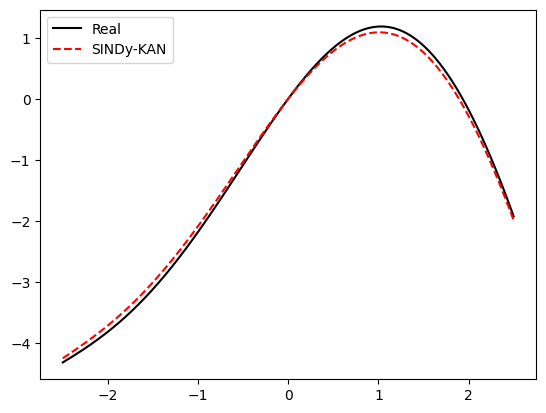

In [51]:
plt.figure()
plt.plot(x.numpy(), y_true.numpy(), label="Real", color="black")
plt.plot(x.numpy(), (Theta @ Xi_final).detach().numpy(), label="SINDy-KAN", linestyle="--", color="red")
plt.legend()
plt.show()